# Configurações

In [43]:
pip install pytorch-msssim

Note: you may need to restart the kernel to use updated packages.


In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter

import os
import csv
import matplotlib.pyplot as plt
import numpy as np
import random
import time

from pytorch_msssim import ssim as ssim_fn
import wandb

from kaggle_secrets import UserSecretsClient

In [45]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Parâmetros
BATCH_SIZE = 32
IMAGE_SIZE = 128
EPOCHS = 60
LEARNING_RATE = 1e-3

LATENT_DIM = 4096

Device: cuda
GPU: Tesla T4


In [46]:
WANDB_PROJECT = "autoencoder-recon-tcc"   
MODEL_NAME    = "vae_wmse_kl_64" # ATENÇÃO trocar a cada experimento

secret = UserSecretsClient()
wandb.login(key=secret.get_secret("WANDB_API_KEY"))

run = wandb.init(
    project=WANDB_PROJECT,
    name=MODEL_NAME,
    config={
        "model":         MODEL_NAME,
        "epochs":        EPOCHS,
        "batch_size":    BATCH_SIZE,
        "image_size":    IMAGE_SIZE,
        "learning_rate": LEARNING_RATE,
        "ssim_warmup":   10,
        "loss_alpha":    0.8,
        "seed":          SEED,
    }
)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


# Dataset

## Split 70/15/15 (Treino/Validação/Teste)

In [47]:
FINAL_PATH = "/kaggle/input/datasets/caiovmfernandesc/dataset-split-final/dataset"

print("Usando dataset já pronto em:")
print(FINAL_PATH)

Usando dataset já pronto em:
/kaggle/input/datasets/caiovmfernandesc/dataset-split-final/dataset


## Preparando para treino

In [48]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(f"{FINAL_PATH}/train", transform=transform)
val_dataset   = datasets.ImageFolder(f"{FINAL_PATH}/val",   transform=transform)
test_dataset  = datasets.ImageFolder(f"{FINAL_PATH}/test",  transform=transform)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

## Checks

In [49]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

print(Counter(train_dataset.targets))
print(Counter(val_dataset.targets))
print(Counter(test_dataset.targets))

x, y = train_dataset[0]
print(x.shape, x.min().item(), x.max().item())

7000 1500 1500
Counter({0: 3500, 1: 3500})
Counter({0: 750, 1: 750})
Counter({0: 750, 1: 750})
torch.Size([3, 64, 64]) 0.0 0.8196078538894653


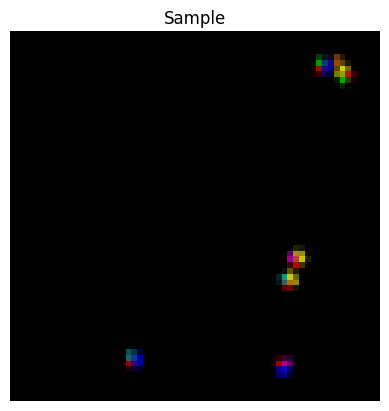

In [50]:
plt.imshow(x.permute(1, 2, 0))
plt.title("Sample")
plt.axis("off")
plt.show()

# Modelos

## Convolutional Autoencoder

In [9]:
class CAE(nn.Module):
   def __init__(self):
       super(CAE, self).__init__()


       # Encoder (reduz resolução espacial por fator 2 a cada camada)
       self.encoder = nn.Sequential(
           nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
           nn.ReLU(),


           nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
           nn.ReLU(),


           nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
           nn.ReLU(),
       )


       # Espaço latente → (64, H/8, W/8)


       # Decoder (aumenta resolução espacial por fator 2 a cada camada)
       self.decoder = nn.Sequential(
           nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
           nn.ReLU(),


           nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
           nn.ReLU(),


           nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
           nn.Sigmoid() # saída [0,1]
       )


   def forward(self, x):
       z = self.encoder(x) # representação latente
       x_hat = self.decoder(z) # reconstrução
       return x_hat

## Sparse Autoencoder

In [32]:
class SAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super(SAE, self).__init__()

        # Encoder: 12288 → 8192 → 4096
        self.encoder = nn.Sequential(
            nn.Flatten(),

            nn.Linear(3 * IMAGE_SIZE * IMAGE_SIZE, 8192),
            nn.ReLU(),

            nn.Linear(8192, latent_dim),
        )

        # Decoder: 4096 → 8192 → 12288
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8192),
            nn.ReLU(),

            nn.Linear(8192, 3 * IMAGE_SIZE * IMAGE_SIZE),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x) # representação latente
        x_hat = self.decoder(z) # reconstrução

        #reshape de volta pra imagem
        x_hat = x_hat.view(-1, 3, IMAGE_SIZE, IMAGE_SIZE)

        return x_hat, z

## Variational Autoencoder

In [51]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder (reduz resolução espacial por fator 2 a cada camada)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
        )

        # Parâmetros da distribuição latente
        self.conv_mu = nn.Conv2d(64, 64, kernel_size=1) # média
        self.conv_logvar = nn.Conv2d(64, 64, kernel_size=1) # log variância

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, 3, 2, 1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) # desvio padrão
        eps = torch.randn_like(std) # ruído
        return mu + eps * std # amostragem via reparametrização

    def forward(self, x):
        x = self.encoder(x)

        mu = self.conv_mu(x)
        logvar = torch.clamp(self.conv_logvar(x), -10, 10)

        z = self.reparameterize(mu, logvar) # amostra latente

        x_hat = self.decoder(z) # reconstrução

        return x_hat, mu, logvar

# Métricas / Loss

In [52]:
def weighted_mse_loss(x, x_hat):

    mask = (x.mean(dim=1, keepdim=True) > 0.05).float()
    weights = 1 + 50 * mask  # pixels relevantes têm peso maior

    loss = weights * (x - x_hat) ** 2
    return loss.mean()

def ssim_loss(x, x_hat):
    # garante que está no range [0, 1]
    x = torch.clamp(x, 0, 1)
    x_hat = torch.clamp(x_hat, 0, 1)

    ssim_val = ssim_fn(x, x_hat, data_range=1.0, size_average=True)

    return 1 - ssim_val  # transforma em loss


def recon_loss_fn(x, x_hat, epoch, alpha=0.8):
    wmse = weighted_mse_loss(x, x_hat)

    # warmup do ssim
    if epoch < 10:
        return wmse, wmse, torch.tensor(0.0, device=x.device)

    ssim = ssim_loss(x, x_hat)
    recon_loss = alpha * wmse + (1 - alpha) * ssim

    return recon_loss, wmse, ssim

def cae_loss(x, x_hat, epoch):
    recon_loss, wmse, ssim = recon_loss_fn(x, x_hat, epoch)
    return recon_loss, wmse, ssim

def sae_loss(x, x_hat, z, epoch, lambda_sparse=0.001):
    recon_loss, wmse, ssim = recon_loss_fn(x, x_hat, epoch)

    sparse_loss = torch.mean(torch.sum(torch.abs(z), dim=1))  # L1 → esparsidade

    loss = recon_loss + lambda_sparse * sparse_loss
    return loss, recon_loss, sparse_loss, wmse, ssim

def vae_loss(x, x_hat, mu, logvar, beta, epoch):
    recon_loss, wmse, ssim = recon_loss_fn(x, x_hat, epoch)

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=[1,2,3])
    )

    loss = recon_loss + beta * kl_loss
    return loss, recon_loss, kl_loss, wmse, ssim

# Treinamento

## Função de treino CAE

In [11]:
def train_epoch_cae(model, loader, optimizer, device, epoch):
    model.train()

    total_loss = 0
    total_wmse = 0
    total_ssim = 0

    for x, _ in loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat = model(x)

        loss, wmse, ssim = cae_loss(x, x_hat, epoch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_wmse += wmse.item()
        total_ssim += ssim.item()

    n = len(loader)

    return (
        total_loss / n,
        total_wmse / n,
        total_ssim / n
    )

## Função de treino SAE

In [33]:
def train_epoch_sae(model, loader, optimizer, device, lambda_sparse, epoch):
    model.train()

    total_loss = 0
    total_recon = 0
    total_sparse = 0
    total_wmse = 0
    total_ssim = 0

    for x, _ in loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, z = model(x)

        loss, recon, sparse, wmse, ssim = sae_loss(x, x_hat, z, epoch, lambda_sparse)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_sparse += sparse.item()
        total_wmse += wmse.item()
        total_ssim += ssim.item()

    n = len(loader)

    return (
        total_loss / n,
        total_recon / n,
        total_sparse / n,
        total_wmse / n,
        total_ssim / n
    )

## Função de treino VAE

In [53]:
def train_epoch_vae(model, loader, optimizer, device, beta, epoch):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0
    total_wmse = 0
    total_ssim = 0

    for x, _ in loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mu, logvar = model(x)

        loss, recon, kl, wmse, ssim = vae_loss(x, x_hat, mu, logvar, beta, epoch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        total_wmse += wmse.item()
        total_ssim += ssim.item()

    n = len(loader)

    return (
        total_loss / n,
        total_recon / n,
        total_kl / n,
        total_wmse / n,
        total_ssim / n
    )

## Função de validação CAE

In [12]:
def eval_epoch_cae(model, loader, device, epoch):
    model.eval()

    total_loss = 0
    total_wmse = 0
    total_ssim = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)

            x_hat = model(x)

            loss, wmse, ssim = cae_loss(x, x_hat, epoch)

            total_loss += loss.item()
            total_wmse += wmse.item()
            total_ssim += ssim.item()

    n = len(loader)

    return (
        total_loss / n,
        total_wmse / n,
        total_ssim / n
    )

## Função de validação SAE

In [34]:
def eval_epoch_sae(model, loader, device, lambda_sparse, epoch):
    model.eval()

    total_loss = 0
    total_recon = 0
    total_sparse = 0
    total_wmse = 0
    total_ssim = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)

            x_hat, z = model(x)

            loss, recon, sparse, wmse, ssim = sae_loss(x, x_hat, z, epoch, lambda_sparse)

            total_loss += loss.item()
            total_recon += recon.item()
            total_sparse += sparse.item()
            total_wmse += wmse.item()
            total_ssim += ssim.item()

    n = len(loader)

    return (
        total_loss / n,
        total_recon / n,
        total_sparse / n,
        total_wmse / n,
        total_ssim / n
    )

## Função de validação VAE

In [54]:
def eval_epoch_vae(model, loader, device, beta, epoch):
    model.eval()

    total_loss = 0
    total_recon = 0
    total_kl = 0
    total_wmse = 0
    total_ssim = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)

            x_hat, mu, logvar = model(x)

            loss, recon, kl, wmse, ssim = vae_loss(x, x_hat, mu, logvar, beta, epoch)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            total_wmse += wmse.item()
            total_ssim += ssim.item()

    n = len(loader)

    return (
        total_loss / n,
        total_recon / n,
        total_kl / n,
        total_wmse / n,
        total_ssim / n
    )

## Setup do treino

In [55]:
LOG_PATH = "/kaggle/working/logs"
os.makedirs(LOG_PATH, exist_ok=True)
 
def init_csv(model_name, fieldnames):
    path = os.path.join(LOG_PATH, f"{model_name}.csv")
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
    return path
 
def append_csv(path, row):
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        writer.writerow(row)

In [56]:
# ATENÇÃO (escolha qual modelo treinar)

# CAE() , SAE() , VAE()
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Loop de treino CAE

In [15]:
start_time = time.time()

csv_fields = ["epoch", "train_loss", "val_loss", "train_wmse", "val_wmse", "train_ssim", "val_ssim"]
csv_path = init_csv(MODEL_NAME, csv_fields)

train_losses = []
val_losses = []

train_wmse_losses = []
train_ssim_losses = []

val_wmse_losses = []
val_ssim_losses = []

for epoch in range(EPOCHS):
    train_loss, train_wmse, train_ssim = train_epoch_cae(model, train_loader, optimizer, device, epoch)
    val_loss, val_wmse, val_ssim = eval_epoch_cae(model, val_loader, device, epoch)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_wmse_losses.append(train_wmse)
    train_ssim_losses.append(train_ssim)

    val_wmse_losses.append(val_wmse)
    val_ssim_losses.append(val_ssim)

    # WandB log
    log_dict = {
        "epoch":      epoch + 1,
        "train/loss": train_loss, "val/loss": val_loss,
        "train/wmse": train_wmse, "val/wmse": val_wmse,
    }

    # SSIM após o warmup
    if epoch >= 10:
        log_dict["train/ssim"] = train_ssim
        log_dict["val/ssim"]   = val_ssim
    wandb.log(log_dict, step=epoch + 1)

    # CSV log (salva tudo, incluindo zeros do warmup)
    append_csv(csv_path, {
        "epoch": epoch + 1,
        "train_loss": train_loss, "val_loss": val_loss,
        "train_wmse": train_wmse, "val_wmse": val_wmse,
        "train_ssim": train_ssim, "val_ssim": val_ssim,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train: {train_loss:.4f} (WMSE: {train_wmse:.4f}, SSIM: {train_ssim:.4f}) | "
        f"Val: {val_loss:.4f} (WMSE: {val_wmse:.4f}, SSIM: {val_ssim:.4f})"
    )

end_time = time.time()
print(f"Tempo total de treino: {end_time - start_time:.2f} segundos")
wandb.log({"train_time_seconds": end_time - start_time})

Epoch 1/20 | Train: 0.1002 (WMSE: 0.1002, SSIM: 0.0000) | Val: 0.0443 (WMSE: 0.0443, SSIM: 0.0000)
Epoch 2/20 | Train: 0.0348 (WMSE: 0.0348, SSIM: 0.0000) | Val: 0.0302 (WMSE: 0.0302, SSIM: 0.0000)
Epoch 3/20 | Train: 0.0279 (WMSE: 0.0279, SSIM: 0.0000) | Val: 0.0258 (WMSE: 0.0258, SSIM: 0.0000)
Epoch 4/20 | Train: 0.0239 (WMSE: 0.0239, SSIM: 0.0000) | Val: 0.0224 (WMSE: 0.0224, SSIM: 0.0000)
Epoch 5/20 | Train: 0.0212 (WMSE: 0.0212, SSIM: 0.0000) | Val: 0.0202 (WMSE: 0.0202, SSIM: 0.0000)
Epoch 6/20 | Train: 0.0192 (WMSE: 0.0192, SSIM: 0.0000) | Val: 0.0188 (WMSE: 0.0188, SSIM: 0.0000)
Epoch 7/20 | Train: 0.0179 (WMSE: 0.0179, SSIM: 0.0000) | Val: 0.0176 (WMSE: 0.0176, SSIM: 0.0000)
Epoch 8/20 | Train: 0.0170 (WMSE: 0.0170, SSIM: 0.0000) | Val: 0.0168 (WMSE: 0.0168, SSIM: 0.0000)
Epoch 9/20 | Train: 0.0162 (WMSE: 0.0162, SSIM: 0.0000) | Val: 0.0162 (WMSE: 0.0162, SSIM: 0.0000)
Epoch 10/20 | Train: 0.0155 (WMSE: 0.0155, SSIM: 0.0000) | Val: 0.0155 (WMSE: 0.0155, SSIM: 0.0000)
Epoch 11/

## Loop de treino SAE

In [37]:
start_time = time.time()

csv_fields = ["epoch","train_loss","val_loss","train_recon","val_recon",
              "train_sparse","val_sparse","train_wmse","val_wmse","train_ssim","val_ssim"]
csv_path = init_csv(MODEL_NAME, csv_fields)

train_losses = []
val_losses = []

train_recon_losses = []
train_sparse_losses = []
train_wmse_losses = []
train_ssim_losses = []

val_recon_losses = []
val_sparse_losses = []
val_wmse_losses = []
val_ssim_losses = []

for epoch in range(EPOCHS):
    lambda_sparse = 1e-3

    train_loss, train_recon, train_sparse, train_wmse, train_ssim = train_epoch_sae(
        model, train_loader, optimizer, device, lambda_sparse, epoch
    )

    val_loss, val_recon, val_sparse, val_wmse, val_ssim = eval_epoch_sae(
        model, val_loader, device, lambda_sparse, epoch
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_recon_losses.append(train_recon)
    train_sparse_losses.append(train_sparse)
    train_wmse_losses.append(train_wmse)
    train_ssim_losses.append(train_ssim)

    val_recon_losses.append(val_recon)
    val_sparse_losses.append(val_sparse)
    val_wmse_losses.append(val_wmse)
    val_ssim_losses.append(val_ssim)

    log_dict = {
        "epoch": epoch+1,
        "train/loss": train_loss,     "val/loss": val_loss,
        "train/recon": train_recon,   "val/recon": val_recon,
        "train/sparse": train_sparse, "val/sparse": val_sparse,
        "train/wmse": train_wmse,     "val/wmse": val_wmse,
    }
    if epoch >= 10:
        log_dict["train/ssim"] = train_ssim
        log_dict["val/ssim"]   = val_ssim
    wandb.log(log_dict, step=epoch+1)
 
    append_csv(csv_path, {
        "epoch": epoch+1,
        "train_loss": train_loss, "val_loss": val_loss,
        "train_recon": train_recon, "val_recon": val_recon,
        "train_sparse": train_sparse, "val_sparse": val_sparse,
        "train_wmse": train_wmse, "val_wmse": val_wmse,
        "train_ssim": train_ssim, "val_ssim": val_ssim,
    })


    print(
        f"Epoch {epoch+1}/{EPOCHS} | λ: {lambda_sparse} | "
        f"Train: {train_loss:.4f} (Recon: {train_recon:.4f}, Sparse: {train_sparse:.4f}, WMSE: {train_wmse:.4f}, SSIM: {train_ssim:.4f}) | "
        f"Val: {val_loss:.4f} (Recon: {val_recon:.4f}, Sparse: {val_sparse:.4f}, WMSE: {val_wmse:.4f}, SSIM: {val_ssim:.4f})"
    )

end_time = time.time()
print(f"Tempo total de treino: {end_time - start_time:.2f} segundos")
wandb.log({"train_time_seconds": end_time - start_time})

Epoch 1/20 | λ: 0.001 | Train: 0.1042 (Recon: 0.0810, Sparse: 23.1475, WMSE: 0.0810, SSIM: 0.0000) | Val: 0.0870 (Recon: 0.0710, Sparse: 15.9933, WMSE: 0.0710, SSIM: 0.0000)
Epoch 2/20 | λ: 0.001 | Train: 0.1076 (Recon: 0.0724, Sparse: 35.1847, WMSE: 0.0724, SSIM: 0.0000) | Val: 0.0762 (Recon: 0.0697, Sparse: 6.5284, WMSE: 0.0697, SSIM: 0.0000)
Epoch 3/20 | λ: 0.001 | Train: 0.0984 (Recon: 0.0693, Sparse: 29.1491, WMSE: 0.0693, SSIM: 0.0000) | Val: 0.0705 (Recon: 0.0677, Sparse: 2.7788, WMSE: 0.0677, SSIM: 0.0000)
Epoch 4/20 | λ: 0.001 | Train: 0.0774 (Recon: 0.0669, Sparse: 10.4761, WMSE: 0.0669, SSIM: 0.0000) | Val: 0.0679 (Recon: 0.0666, Sparse: 1.3207, WMSE: 0.0666, SSIM: 0.0000)
Epoch 5/20 | λ: 0.001 | Train: 0.0681 (Recon: 0.0656, Sparse: 2.4394, WMSE: 0.0656, SSIM: 0.0000) | Val: 0.0670 (Recon: 0.0658, Sparse: 1.1995, WMSE: 0.0658, SSIM: 0.0000)
Epoch 6/20 | λ: 0.001 | Train: 0.0661 (Recon: 0.0646, Sparse: 1.5283, WMSE: 0.0646, SSIM: 0.0000) | Val: 0.0662 (Recon: 0.0651, Sparse:

## Loop de treino VAE

In [57]:
start_time = time.time()

train_losses = []
val_losses = []

train_recon_losses = []
train_kl_losses = []
train_wmse_losses = []
train_ssim_losses = []

val_recon_losses = []
val_kl_losses = []
val_wmse_losses = []
val_ssim_losses = []

csv_fields = ["epoch","train_loss","val_loss","train_recon","val_recon",
              "train_kl","val_kl","train_wmse","val_wmse","train_ssim","val_ssim"]
csv_path = init_csv(MODEL_NAME, csv_fields)

for epoch in range(EPOCHS):
    beta = 0.001

    train_loss, train_recon, train_kl, train_wmse, train_ssim = train_epoch_vae(
        model, train_loader, optimizer, device, beta, epoch
    )

    val_loss, val_recon, val_kl, val_wmse, val_ssim = eval_epoch_vae(
        model, val_loader, device, beta, epoch
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)
    train_wmse_losses.append(train_wmse)
    train_ssim_losses.append(train_ssim)

    val_recon_losses.append(val_recon)
    val_kl_losses.append(val_kl)
    val_wmse_losses.append(val_wmse)
    val_ssim_losses.append(val_ssim)

    log_dict = {
        "epoch": epoch+1,
        "train/loss": train_loss,   "val/loss": val_loss,
        "train/recon": train_recon, "val/recon": val_recon,
        "train/kl": train_kl,       "val/kl": val_kl,
        "train/wmse": train_wmse,   "val/wmse": val_wmse,
    }
    if epoch >= 10:
        log_dict["train/ssim"] = train_ssim
        log_dict["val/ssim"]   = val_ssim
    wandb.log(log_dict, step=epoch+1)
 
    append_csv(csv_path, {
        "epoch": epoch+1,
        "train_loss": train_loss, "val_loss": val_loss,
        "train_recon": train_recon, "val_recon": val_recon,
        "train_kl": train_kl, "val_kl": val_kl,
        "train_wmse": train_wmse, "val_wmse": val_wmse,
        "train_ssim": train_ssim, "val_ssim": val_ssim,
    })

    
    print(
        f"Epoch {epoch+1}/{EPOCHS} | Beta: {beta:.3f} | "
        f"Train: {train_loss:.4f} (Recon: {train_recon:.4f}, KL: {train_kl:.4f}, WMSE: {train_wmse:.4f}, SSIM: {train_ssim:.4f}) | "
        f"Val: {val_loss:.4f} (Recon: {val_recon:.4f}, KL: {val_kl:.4f}, WMSE: {val_wmse:.4f}, SSIM: {val_ssim:.4f})"
    )

end_time = time.time()
print(f"Tempo total de treino: {end_time - start_time:.2f} segundos")
wandb.log({"train_time_seconds": end_time - start_time})

Epoch 1/20 | Beta: 0.001 | Train: 0.1278 (Recon: 0.1260, KL: 1.7250, WMSE: 0.1260, SSIM: 0.0000) | Val: 0.0758 (Recon: 0.0723, KL: 3.5976, WMSE: 0.0723, SSIM: 0.0000)
Epoch 2/20 | Beta: 0.001 | Train: 0.0738 (Recon: 0.0697, KL: 4.0881, WMSE: 0.0697, SSIM: 0.0000) | Val: 0.0726 (Recon: 0.0678, KL: 4.7251, WMSE: 0.0678, SSIM: 0.0000)
Epoch 3/20 | Beta: 0.001 | Train: 0.0720 (Recon: 0.0676, KL: 4.3899, WMSE: 0.0676, SSIM: 0.0000) | Val: 0.0714 (Recon: 0.0668, KL: 4.6900, WMSE: 0.0668, SSIM: 0.0000)
Epoch 4/20 | Beta: 0.001 | Train: 0.0712 (Recon: 0.0668, KL: 4.3741, WMSE: 0.0668, SSIM: 0.0000) | Val: 0.0709 (Recon: 0.0664, KL: 4.4578, WMSE: 0.0664, SSIM: 0.0000)
Epoch 5/20 | Beta: 0.001 | Train: 0.0707 (Recon: 0.0662, KL: 4.5154, WMSE: 0.0662, SSIM: 0.0000) | Val: 0.0703 (Recon: 0.0656, KL: 4.7053, WMSE: 0.0656, SSIM: 0.0000)
Epoch 6/20 | Beta: 0.001 | Train: 0.0700 (Recon: 0.0649, KL: 5.1459, WMSE: 0.0649, SSIM: 0.0000) | Val: 0.0696 (Recon: 0.0644, KL: 5.2223, WMSE: 0.0644, SSIM: 0.0000

## Salvando modelo

In [58]:
SAVE_PATH = "/kaggle/working/models"
os.makedirs(SAVE_PATH, exist_ok=True)

# CONFERIR sempre o nome do modelo !!
torch.save(
    model.state_dict(),
    os.path.join(SAVE_PATH, "vae_wmse_kl_64.pth")
)

# Resultados

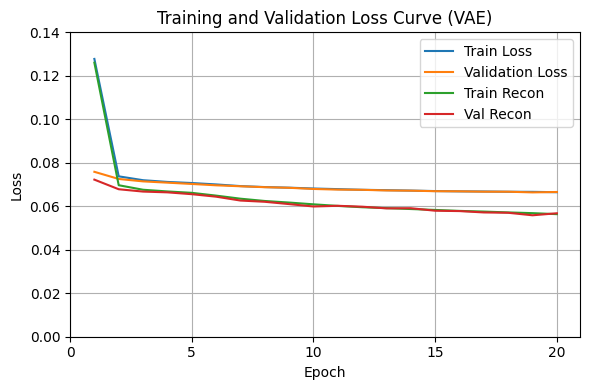

In [59]:
SSIM_WARMUP = 10

epochs = list(range(1, len(train_losses) + 1))
epochs_ssim = list(range(SSIM_WARMUP + 1, len(train_losses) + 1))

plt.figure(figsize=(6,4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

#plt.plot(epochs, train_wmse_losses, label="Train WMSE", linestyle="--")
#plt.plot(epochs, val_wmse_losses, label="Val WMSE", linestyle="--")

#plt.plot(epochs_ssim, train_ssim_losses[SSIM_WARMUP:], label="Train SSIM", linestyle=":", color="purple")
#plt.plot(epochs_ssim, val_ssim_losses[SSIM_WARMUP:], label="Val SSIM", linestyle=":", color="blue")

# plots só para SAE e VAE (comentar se modelo for CAE)
plt.plot(epochs, train_recon_losses, label="Train Recon")
plt.plot(epochs, val_recon_losses, label="Val Recon")

plt.ylim(0, 0.14)

plt.title("Training and Validation Loss Curve (CAE)") # ATENÇÃO (nome do gráfico)
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ticks de 5 em 5
plt.xticks(range(0, 61, 5))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [60]:
def find_image_in_datasets(image_name, datasets):
    for dataset in datasets:
        for i, (path, _) in enumerate(dataset.samples):
            if os.path.basename(path) == image_name:
                return dataset[i][0]  # já retorna transformado
    raise ValueError(f"{image_name} não encontrada em nenhum dataset")

# usando sempre as mesmas imagens para ver reconstrução
fixed_image_names = [
    "img_game_0002.png",
    "img_game_0012.png",
    "img_game_0023.png",
    "img_game_0033.png",
    "img_game_0035.png",
]

datasets_list = [train_dataset, val_dataset, test_dataset]

fixed_x = torch.stack([
    find_image_in_datasets(name, datasets_list)
    for name in fixed_image_names
])

# Usando sempre as mesmas imagens para visualizar reconstrução
# indices = [0, 1, 2, 3, 4]
# fixed_x = torch.stack([test_dataset[i][0] for i in indices])

In [19]:
#CAE

model.eval()

with torch.no_grad():
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    z = model.encoder(dummy)

    latent_shape = tuple(z.shape[1:])
    latent_size = z.numel()

    if len(latent_shape) == 3:
        x, y, z_dim = latent_shape
        flat_size = x * y * z_dim
    else:
        flat_size = latent_size

print(f"\n===== CAE =====")
print(f"Latent shape: {latent_shape}")
print(f"Latent size (x*y*z): {flat_size}")

test_loss = 0
test_wmse = 0
test_ssim = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        x_hat = model(x)

        # valor fixo (20) usado somente para ativar SSIM (valor > 10)
        loss, wmse, ssim = cae_loss(x, x_hat, 20)

        test_loss += loss.item()
        test_wmse += wmse.item()
        test_ssim += ssim.item()

n = len(test_loader)

test_loss /= n
test_wmse /= n
test_ssim /= n

print(f"Test Loss: {test_loss:.4f}")
print(f"Test WMSE: {test_wmse:.4f}")
print(f"Test SSIM Loss: {test_ssim:.4f}")


===== CAE =====
Latent shape: (64, 8, 8)
Latent size (x*y*z): 4096
Test Loss: 0.0095
Test WMSE: 0.0095
Test SSIM Loss: 0.0000


In [41]:
#SAE

model.eval()

with torch.no_grad():
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    z = model.encoder(dummy)

print(f"\n===== SAE =====")
print(f"Latent dim: {z.shape[-1]}")

test_loss = 0
test_recon = 0
test_sparse = 0
test_wmse = 0
test_ssim = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        x_hat, z = model(x)

        loss, recon, sparse, wmse, ssim = sae_loss(x, x_hat, z, 20)

        test_loss += loss.item()
        test_recon += recon.item()
        test_sparse += sparse.item()
        test_wmse += wmse.item()
        test_ssim += ssim.item()

n = len(test_loader)

test_loss /= n
test_recon /= n
test_sparse /= n
test_wmse /= n
test_ssim /= n

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Recon: {test_recon:.4f}")
print(f"Test Sparse: {test_sparse:.4f}")
print(f"Test WMSE: {test_wmse:.4f}")
print(f"Test SSIM Loss: {test_ssim:.4f}")


===== SAE =====
Latent dim: 4096
Test Loss: 0.0657
Test Recon: 0.0644
Test Sparse: 1.2282
Test WMSE: 0.0644
Test SSIM Loss: 0.0000


In [61]:
# VAE

model.eval()

with torch.no_grad():
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)

    x = model.encoder(dummy)
    mu = model.conv_mu(x)

    latent_shape = tuple(mu.shape[1:])
    latent_size = mu.numel()

    if len(latent_shape) == 3:
        x, y, z_dim = latent_shape
        flat_size = x * y * z_dim
    else:
        flat_size = latent_size

print(f"\n===== VAE =====")
print(f"Latent shape: {latent_shape}")
print(f"Latent size (x*y*z): {flat_size}")

beta = 0.001

test_loss = 0
test_recon = 0
test_kl = 0
test_wmse = 0
test_ssim = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        x_hat, mu, logvar = model(x)

        loss, recon, kl, wmse, ssim = vae_loss(x, x_hat, mu, logvar, beta, 20)

        test_loss += loss.item()
        test_recon += recon.item()
        test_kl += kl.item()
        test_wmse += wmse.item()
        test_ssim += ssim.item()

n = len(test_loader)

test_loss /= n
test_recon /= n
test_kl /= n
test_wmse /= n
test_ssim /= n

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Recon: {test_recon:.4f}")
print(f"Test KL: {test_kl:.4f}")
print(f"Test WMSE: {test_wmse:.4f}")
print(f"Test SSIM Loss: {test_ssim:.4f}")


===== VAE =====
Latent shape: (64, 8, 8)
Latent size (x*y*z): 4096
Test Loss: 0.0664
Test Recon: 0.0566
Test KL: 9.8071
Test WMSE: 0.0566
Test SSIM Loss: 0.0000


In [17]:
MODEL_PATH = "/kaggle/input/models/caiovmfernandesc/cae-wmse-ssim-128-ep30-ld1024/pytorch/default/1/cae_wmse_ssim_128_ep30_LD1024.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

CAE(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (7): Re

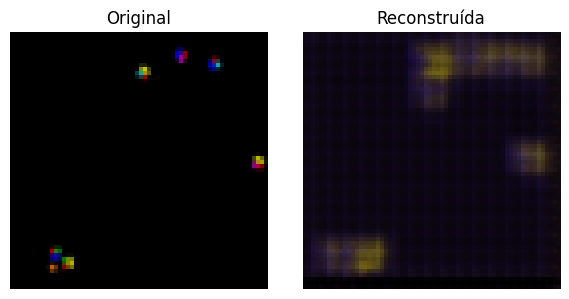

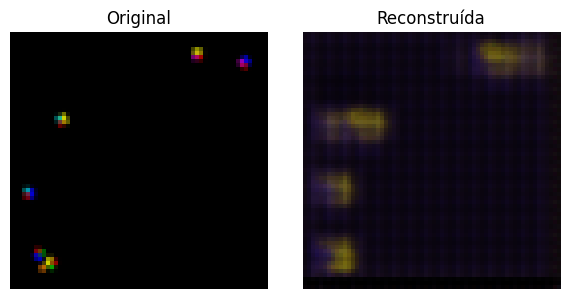

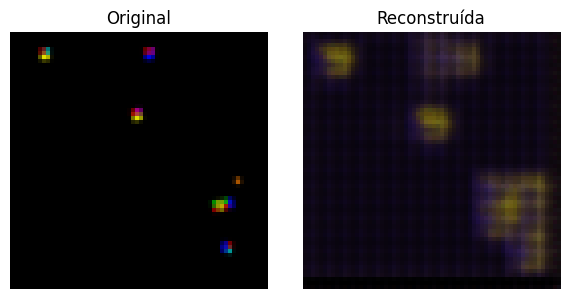

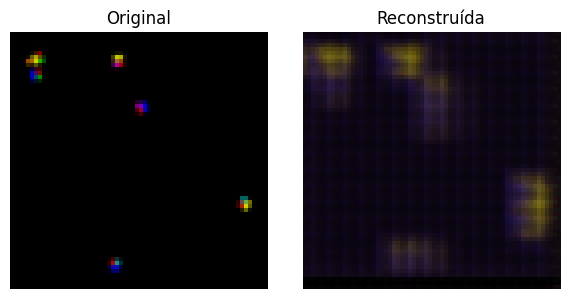

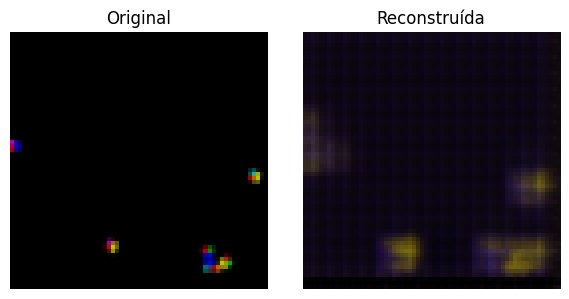

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/kl,▁▃▃▃▃▄▄▅▅▆▆▆▆▇▇▇▇███
train/loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/recon,█▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/wmse,█▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_time_seconds,▁
val/kl,▁▂▂▂▂▃▄▄▅▆▅▅▆▆▆▇▇▇█▇
val/loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
val/recon,█▆▆▆▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁
val/wmse,█▆▆▆▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁
epoch,20


In [62]:
model.eval()

x = fixed_x.to(device)

model_type = "cae"  # ATENÇÃO (trocar para modelo treinado)

with torch.no_grad():
    if model_type == "cae":
        x_hat = model(x)

    elif model_type == "sae":
        x_hat, _ = model(x)

    elif model_type == "vae":
        # inferência determinística !!
        _, mu, _ = model(x)
        x_hat = model.decoder(mu)

# número de exemplos
n = 5

for i in range(n):
    plt.figure(figsize=(6,3))

    # 🔹 Original
    plt.subplot(1, 2, 1)
    plt.imshow(x[i].cpu().permute(1,2,0))
    plt.title("Original")
    plt.axis("off")

    # 🔹 Reconstruída
    plt.subplot(1, 2, 2)
    plt.imshow(x_hat[i].cpu().permute(1,2,0))
    plt.title("Reconstruída")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

wandb.finish()